In [1]:
#other
import os
import numpy as np
import pandas as pd
import pickle as pkl
from copy import deepcopy
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, wilcoxon
from runs import multi_subject_experiments
from utils_multisubject import read_files, create_window_df

#sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, r2_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, LeaveOneGroupOut
from sklearn.utils import shuffle

#pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

In [2]:
loaded = False
experiment_number = 3

# Parameters to Change
seconds = 4.5

 # Window Duration
step_size = 10

In [3]:
save_model_results = True

TARGET_LABEL = "binary_label"
# TARGET_LABEL = "discrete_label"

# Model ParamsTrue
EPOCHS = 30
BATCH_SIZE = 64
HIDDEN_DIM = 64
LEARNING_RATE = 0.001

# Random State
random_state = 92

#choose model
model_type = "LSTM" #CNN, LSTM

# Shuffle Data and Saving Desults
shuffle_data = True
save_plots = False

# test sizes
finetuning_test_size = 0.05
test_size = 0.2

### Experiment Set-Up

### Setup
Identify the fNIRS data source folder, determine which experiment set to run, and calculate the window length.

In [4]:
def set_all_seeds(seed: int = 42) -> None:
    """Sets seeds for reproducibility across PyTorch, NumPy, and Python's random module."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    # random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU setups
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Call this function at the beginning of your script
set_all_seeds(random_state)

# Window Parameters
window_size = int(seconds*5.2) #Calculating window size from fnirs frame rate

# Source Folders
source_folder = "/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/fNIRS/LabeledData"

# Channels Used
channels = ["L_O_DSphi", "L_D_DSphi", "R_D_DSphi", "R_O_DSphi",	"L_O_DSI",	"R_D_DSI",	"R_O_DSI",	"L_D_DSI"]

# Label Mapping
labels_for_windows = ["discrete_optimal", "binary_optimal", "continuous_optimal"]

# Load Training List and Conditions from runs.py
participant_list, conditions_list, experiment_name = multi_subject_experiments[experiment_number].values()

# List of Participants and Conditions Used in Training
participants = str(participant_list).replace("'", "")
conditions = str(conditions_list)[2:-2].replace("'", "")

if TARGET_LABEL == "binary_label":
    granularity = "binary"
    NUM_CLASSES = 2
elif TARGET_LABEL == "discrete_label":
    NUM_CLASSES = 3
    granularity = "multiclass"

if model_type != "MLP":
    HIDDEN_DIM = None


print("Experiment Name: ", experiment_name)
print("\nTraining List: ", participants, "\nTraining Conditions: ", conditions) 

Experiment Name:  multiSubject

Training List:  [3, 5, 6, 7, 8, 10, 12, 20, 23, 24, 25] 
Training Conditions:  LW


In [5]:
if not loaded:
    # Read files for training data
    all_data = read_files(participant_list=participant_list, source_folder_1 = source_folder, conditions=conditions_list)

    df_data_all = pd.DataFrame()
    df_labels_all = pd.DataFrame()
    

    # Create windows
    for key in all_data.keys():
        window_data, window_labels = create_window_df(all_data[key], window_size=window_size, step_size=step_size, labels=labels_for_windows, features=channels)
        window_data["Key"] = key
        window_labels["Key"] = key
        # print(key, "is done")
        df_data_all = pd.concat([df_data_all, window_data], ignore_index=True)
        df_labels_all = pd.concat([df_labels_all, window_labels], ignore_index=True)

    df_data_all.drop(columns=["start_timestamp", "end_timestamp"], inplace=True)

    loaded = True

007_LW_LabeledData.csv
024_LW_LabeledData.csv
012_LW_LabeledData.csv
010_LW_LabeledData.csv
020_LW_LabeledData.csv
023_LW_LabeledData.csv
003_LW_LabeledData.csv
005_LW_LabeledData.csv
008_LW_LabeledData.csv
025_LW_LabeledData.csv
006_LW_LabeledData.csv


### Separate Data into Inputs and Labels

In [6]:
def create_train_data(df_data, df_labels, finetune=False):
    
    df = pd.concat([df_data.reset_index(drop=True), df_labels.reset_index(drop=True)], axis=1)
    
    min_discrete = int(df['discrete_label'].value_counts().min())
    df_balanced_discrete = df.groupby('discrete_label', group_keys=False).apply(lambda x: x.sample(min_discrete, random_state=random_state, replace=True))

    #downsample binary labels
    min_binary = int(df['binary_label'].value_counts().min())
    print("Minimum count for binary_label:", min_binary)
    df_balanced_binary = df.groupby('binary_label', group_keys=False).apply(lambda x: x.sample(min_binary, random_state=random_state, replace=True))

    #separate features and labels
    X_binary = df_balanced_binary[df_data.columns]
    X_discrete = df_balanced_discrete[df_data.columns]
    X_continuous = df_data[df_data.columns]

    y_discrete = df_balanced_discrete['discrete_label']
    y_binary = df_balanced_binary['binary_label']
    y_continuous = df['continuous_label']

    return X_continuous, X_binary, X_discrete, y_binary, y_discrete, y_continuous

In [7]:
class CNN1DClassifier(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(CNN1DClassifier, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x): 
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.global_pool(x).squeeze(-1)  
        x = self.dropout(x)
        return self.fc(x)
    
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, num_classes=2, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1])
    
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2, dropout=0.3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

class fNIRSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [8]:
set_all_seeds(random_state)


# choose multi or binary class
features = df_data_all.drop(columns=["Key"])
labels = df_labels_all[TARGET_LABEL].reset_index(drop=True)

print("Label counts:\n", labels.value_counts())



if granularity == "binary":
    _, features, _, labels, _, _ = create_train_data(df_data=features, df_labels=df_labels_all)
    print("Binary label counts:\n", labels.value_counts())

if granularity == "multiclass":
    _, _, features, _, labels, _ = create_train_data(df_data=features, df_labels=df_labels_all)
    print("Discrete label counts:\n", labels.value_counts())

# Normalize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
X_df = pd.DataFrame(features)
y_df = labels

# Split
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df,
    test_size=0.2, shuffle=True, stratify=y_df, random_state=random_state)

# Reshape for LSTM
X_train_lstm = X_train.to_numpy().reshape(X_train.shape[0], 1, -1)
X_test_lstm = X_test.to_numpy().reshape(X_test.shape[0], 1, -1)

#Reshape for CNN
X_train_cnn = np.transpose(X_train_lstm, (0, 2, 1))
X_test_cnn = np.transpose(X_test_lstm, (0, 2, 1))

#Reshape for MLP
X_train_mlp = X_train.to_numpy()
X_test_mlp = X_test.to_numpy()
print(X_train_mlp.shape)
print(X_train_lstm.shape)
print(X_train_cnn.shape)

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

train_dataset_lstm = fNIRSDataset(X_train_lstm, y_train_np)
test_dataset_lstm = fNIRSDataset(X_test_lstm, y_test_np)

train_dataset_cnn = fNIRSDataset(X_train_cnn, y_train_np)
test_dataset_cnn = fNIRSDataset(X_test_cnn, y_test_np)

train_dataset_mlp = fNIRSDataset(X_train_mlp, y_train_np)
test_dataset_mlp = fNIRSDataset(X_test_mlp, y_train_np)

Label counts:
 binary_label
0    950
1    280
Name: count, dtype: int64
Minimum count for binary_label: 280
Binary label counts:
 binary_label
0    280
1    280
Name: count, dtype: int64
(448, 48)
(448, 1, 48)
(448, 48, 1)


/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_26049/2031835642.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced_discrete = df.groupby('discrete_label', group_keys=False).apply(lambda x: x.sample(min_discrete, random_state=random_state, replace=True))
/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_26049/2031835642.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced_

In [9]:
if model_type == "LSTM":
    INPUT_SIZE = X_train_lstm.shape[-1]

    model = LSTMClassifier(input_size=INPUT_SIZE, num_classes=NUM_CLASSES)
    train_loader = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset_lstm, batch_size=BATCH_SIZE)
elif model_type == "CNN":
    INPUT_SIZE = X_train_cnn.shape[1]
    model = CNN1DClassifier(input_channels=INPUT_SIZE, num_classes=NUM_CLASSES)
    train_loader = DataLoader(train_dataset_cnn, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset_cnn, batch_size=BATCH_SIZE)
elif model_type == "MLP":
    INPUT_SIZE = X_train_mlp.shape[-1]
    print(INPUT_SIZE)
    model = MLPClassifier(input_dim=INPUT_SIZE, hidden_dim=HIDDEN_DIM, output_dim=NUM_CLASSES)
    train_loader = DataLoader(train_dataset_mlp, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset_mlp, batch_size=BATCH_SIZE)
else:
    ValueError("No Model Exists for that Value")



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [10]:
def create_report(report, lopo=False):
    def safe_get(class_id, metric):
        try:
            value = report[str(class_id)][metric]
        except:
            value = None
    
        return value

    final_report = {
        "Classifier": model_type,
        "Macro F1": report['macro avg']['f1-score'],
        "Macro Recall": report['macro avg']['recall'],
        "Macro Precision": report['macro avg']['precision'],
        "Class0 Recall": safe_get(0, 'recall'),
        "Class1 Recall": safe_get(1, 'recall'),
        "Class2 Recall": safe_get(2, 'recall'),
        "Class0 Precision": safe_get(0, 'precision'),
        "Class1 Precision": safe_get(1, 'precision'),
        "Class2 Precision": safe_get(2, 'precision'),
        "Class0 F1": safe_get(0, 'f1-score'),
        "Class1 F1": safe_get(1, 'f1-score'),
        "Class2 F1": safe_get(2, 'f1-score'),
        "TrainParticipants": str(participant_list),
        "TestParticipants": str(participant_list),
        "TrainConditions": str(conditions),
        "TestConditions": str(conditions),
        "Experiment": experiment_number,
        "RandomState": random_state,
        "WindowDuration": seconds,
        "WindowStepSize": step_size,
        "BatchSize": BATCH_SIZE,
        "LearningRate": LEARNING_RATE,
        "HiddenDim": HIDDEN_DIM,
        "Epochs": EPOCHS
    }
    return final_report


In [11]:
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = F.cross_entropy(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == y).sum().item()
        n += y.size(0)

    accuracy = correct / n if n else 0.0
    return total_loss / max(len(dataloader), 1), accuracy

@torch.no_grad()
def evaluate(model, dataloader, device, return_report=False):
    model.eval()
    y_true, y_pred = [], []
    correct, n = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        preds = outputs.argmax(1)

        y_true.extend(y.tolist())
        y_pred.extend(preds.tolist())
        correct += (preds == y).sum().item()
        n += y.size(0)

    accuracy = correct / n if n else 0.0
    macro_f1 = f1_score(y_true, y_pred, average="macro") if n else 0.0

    if return_report:
        rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        pretty_report = classification_report(y_true, y_pred, output_dict=False, zero_division=0)

        report = create_report(rep)
        return accuracy, macro_f1, report, pretty_report
    return accuracy, macro_f1

def append_report_to_csv(report_df, csv_path, metadata=None):
    df = pd.DataFrame(report_df, index=[0])

    if os.path.exists(csv_path):
        df.to_csv(csv_path, index=False, mode="a", header=False)
    else:
        df.to_csv(csv_path, index=False, mode="a", header=True)



csv_path = "results/deep_data/multisubject_{}.csv".format(granularity)

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(model, test_loader, device, return_report=False)
    print(f"Epoch {epoch:03d} | train_acc={tr_acc:.3f} | val_acc={val_acc:.3f} | val_macroF1={val_f1:.3f}")

test_acc, test_f1, test_rep, pretty_report = evaluate(model, test_loader, device, return_report=True)

if save_model_results:
    torch.save({
            'epoch': EPOCHS,
            'model_state_dict': model.state_dict(),
            }, f"{model_type}_{participant_list}_{granularity}")
print(pretty_report)

if save_model_results:
    append_report_to_csv(test_rep, csv_path)


Epoch 000 | train_acc=0.504 | val_acc=0.464 | val_macroF1=0.377
Epoch 001 | train_acc=0.536 | val_acc=0.500 | val_macroF1=0.435
Epoch 002 | train_acc=0.542 | val_acc=0.500 | val_macroF1=0.472
Epoch 003 | train_acc=0.567 | val_acc=0.554 | val_macroF1=0.544
Epoch 004 | train_acc=0.569 | val_acc=0.545 | val_macroF1=0.538
Epoch 005 | train_acc=0.583 | val_acc=0.562 | val_macroF1=0.558
Epoch 006 | train_acc=0.596 | val_acc=0.554 | val_macroF1=0.551
Epoch 007 | train_acc=0.614 | val_acc=0.554 | val_macroF1=0.551
Epoch 008 | train_acc=0.625 | val_acc=0.589 | val_macroF1=0.589
Epoch 009 | train_acc=0.661 | val_acc=0.607 | val_macroF1=0.607
Epoch 010 | train_acc=0.676 | val_acc=0.598 | val_macroF1=0.597
Epoch 011 | train_acc=0.676 | val_acc=0.616 | val_macroF1=0.615
Epoch 012 | train_acc=0.681 | val_acc=0.625 | val_macroF1=0.624
Epoch 013 | train_acc=0.694 | val_acc=0.625 | val_macroF1=0.624
Epoch 014 | train_acc=0.717 | val_acc=0.679 | val_macroF1=0.678
Epoch 015 | train_acc=0.728 | val_acc=0.

In [12]:
set_all_seeds(random_state)

groups = df_labels_all['Key'].values

unique_groups = set(groups)


logo = LeaveOneGroupOut()
accuracies, precisions, f1s, recalls, reports = [], [], [], [], []

#convert full dataset to numpy and scale
X_full = scaler.fit_transform(df_data_all.drop(columns=["Key"]))
y_full = df_labels_all[TARGET_LABEL].values

#reshape
X_full_lstm = X_full.reshape(X_full.shape[0], 1, -1)
X_full_cnn = np.transpose(X_full_lstm, (0, 2, 1))  
X_full_mlp = X_full
i = 0

for i, (train_idx, test_idx) in enumerate(logo.split(X_full, y_full, groups)):
    diff2 = list(set(groups) - set(groups[train_idx]))
    print(diff2[0][1:-2])

    if model_type == "CNN":
        X_train_cv, X_test_cv = X_full_cnn[train_idx], X_full_cnn[test_idx]
        model = CNN1DClassifier(input_channels=INPUT_SIZE, num_classes=NUM_CLASSES)
    elif model_type == "LSTM":
        X_train_cv, X_test_cv = X_full_lstm[train_idx], X_full_lstm[test_idx]
        model = LSTMClassifier(input_size=INPUT_SIZE, num_classes=NUM_CLASSES)
    elif model_type == "MLP":
        X_train_cv, X_test_cv = X_full_mlp[train_idx], X_full_mlp[test_idx]
        model = MLPClassifier(input_dim=INPUT_SIZE, output_dim=NUM_CLASSES)
        
    y_train_cv, y_test_cv = y_full[train_idx], y_full[test_idx]

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_ds = fNIRSDataset(X_train_cv, y_train_cv)
    test_ds = fNIRSDataset(X_test_cv, y_test_cv)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    for i, epoch in enumerate(range(EPOCHS)):
        try:
            train_epoch(model, train_loader, optimizer)
        except:
            pass

    # LOPO
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for i, (X, y) in enumerate(test_loader):
            X, y = X.to(device), y.to(device)
            preds = model(X).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    prec = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")

    report = classification_report(all_labels, all_preds)
    report_dict = classification_report(all_labels, all_preds, output_dict=True)

    final_report = create_report(report_dict)
    final_report["TestParticipants"] = diff2[0][1:-2]

    if save_model_results:
        append_report_to_csv(final_report, csv_path = "results/deep_data/multisubject_{}CV.csv".format(granularity))
    
    accuracies.append(acc)
    recalls.append(recall)
    precisions.append(prec)
    f1s.append(f1)
    reports.append(report_dict)
    print(report)
    print(f"Validation Participant Accuracy: {acc:.4f}, F1: {f1:.4f}, Recall {recall:.4f}, Precision: {prec:.4f}")

print(f"Mean Participant Accuracy: {np.mean(accuracies):.4f}, F1: {np.mean(f1s):.4f}, Recall {np.mean(recalls):.4f}, Precision: {np.mean(precisions):.4f}")


03
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        84
           1       0.21      1.00      0.35        23

    accuracy                           0.21       107
   macro avg       0.11      0.50      0.18       107
weighted avg       0.05      0.21      0.08       107

Validation Participant Accuracy: 0.2150, F1: 0.1769, Recall 0.5000, Precision: 0.1075
05
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        83
           1       0.29      1.00      0.45        34

    accuracy                           0.29       117
   macro avg       0.15      0.50      0.23       117
weighted avg       0.08      0.29      0.13       117

Validation Participant Accuracy: 0.2906, F1: 0.2252, Recall 0.5000, Precision: 0.1453
06
              precision    recall  f1-score   support

           0       0.64      0.07      0.13        98
           1       0.23      0.87      0.36        31

 

/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

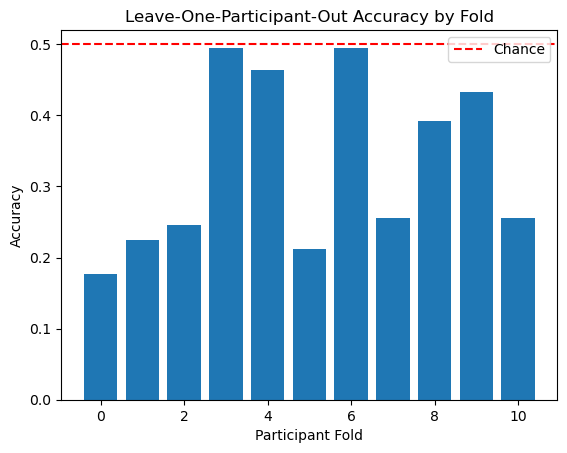

In [13]:
plt.bar(range(len(f1s)), f1s)
plt.axhline(0.5, color='red', linestyle='--', label='Chance')
plt.xlabel("Participant Fold")
plt.ylabel("Accuracy")
plt.title("Leave-One-Participant-Out Accuracy by Fold")
plt.legend()
plt.show()

In [14]:
set_all_seeds(random_state)

groups = df_labels_all['Key'].values

unique_groups = set(groups)


logo = LeaveOneGroupOut()
accuracies, precisions, f1s, recalls, reports = [], [], [], [], []

i = 0

for i, (train_idx, test_idx) in enumerate(logo.split(X_full, y_full, groups)):
    diff2 = list(set(groups) - set(groups[train_idx]))

    print(diff2[0][1:-2])

    if model_type == "CNN":
        X_train_cv, X_test_cv = X_full_cnn[train_idx], X_full_cnn[test_idx]
        model = CNN1DClassifier(input_channels=INPUT_SIZE, num_classes=NUM_CLASSES)
    elif model_type == "LSTM":
        X_train_cv, X_test_cv = X_full_lstm[train_idx], X_full_lstm[test_idx]
        model = LSTMClassifier(input_size=INPUT_SIZE, num_classes=NUM_CLASSES)
    elif model_type == "MLP":
        X_train_cv, X_test_cv = X_full_mlp[train_idx], X_full_mlp[test_idx]
        model = MLPClassifier(input_dim=INPUT_SIZE, output_dim=NUM_CLASSES)

    y_train_cv, y_test_cv = y_full[train_idx], y_full[test_idx]

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    

    train_ds = fNIRSDataset(X_train_cv, y_train_cv)
    test_ds = fNIRSDataset(X_test_cv, y_test_cv)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    try:
        X_train_finetune, X_test_finetune, y_train_finetune, y_test_finetune = train_test_split(X_test_cv, y_test_cv, test_size=finetuning_test_size, stratify=y_test_cv, shuffle=True, random_state=random_state)
    except:
        continue
    
    print(pd.DataFrame(y_train_finetune).value_counts())   

    train_finetune = fNIRSDataset(X_train_finetune, y_train_finetune)
    test_finetune = fNIRSDataset(X_test_finetune, y_test_finetune)
    train_loader_finetune = DataLoader(train_finetune, batch_size=BATCH_SIZE, shuffle=True)
    test_loader_finetune = DataLoader(test_finetune, batch_size=BATCH_SIZE)

    for i, epoch in enumerate(range(20)):
        try:
            train_epoch(model, train_loader, optimizer)
            train_epoch(model, train_loader_finetune, optimizer)
        except:
            pass

    # LOPO
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for i, (X, y) in enumerate(test_loader_finetune):
            X, y = X.to(device), y.to(device)
            preds = model(X).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    prec = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")

    report = classification_report(all_labels, all_preds)
    report_dict = classification_report(all_labels, all_preds, output_dict=True)

    final_report = create_report(report_dict)
    final_report["TestParticipants"] = diff2[0][1:-2]

    if save_model_results:
        append_report_to_csv(final_report, csv_path = "results/deep_data/finetuning_{}.csv".format(granularity))
    
    accuracies.append(acc)
    recalls.append(recall)
    precisions.append(prec)
    f1s.append(f1)
    reports.append(report_dict)
    print(report)
    print(f"Validation Participant Accuracy: {acc:.4f}, F1: {f1:.4f}, Recall {recall:.4f}, Precision: {prec:.4f}")

print(f"Mean Participant Accuracy: {np.mean(accuracies):.4f}, F1: {np.mean(f1s):.4f}, Recall {np.mean(recalls):.4f}, Precision: {np.mean(precisions):.4f}")


03
0
0    79
1    22
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.17      1.00      0.29         1

    accuracy                           0.17         6
   macro avg       0.08      0.50      0.14         6
weighted avg       0.03      0.17      0.05         6

Validation Participant Accuracy: 0.1667, F1: 0.1429, Recall 0.5000, Precision: 0.0833
05
0
0    79
1    32
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.33      1.00      0.50         2

    accuracy                           0.33         6
   macro avg       0.17      0.50      0.25         6
weighted avg       0.11      0.33      0.17         6

Validation Participant Accuracy: 0.3333, F1: 0.2500, Recall 0.5000, Precision: 0.1667
06
0
0    93
1    29
Name: count, dtype: int64
              precision    recall

/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.17      1.00      0.29         1

    accuracy                           0.17         6
   macro avg       0.08      0.50      0.14         6
weighted avg       0.03      0.17      0.05         6

Validation Participant Accuracy: 0.1667, F1: 0.1429, Recall 0.5000, Precision: 0.0833
23
0
0    60
1    16
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1       0.33      1.00      0.50         1

    accuracy                           0.60         5
   macro avg       0.67      0.75      0.58         5
weighted avg       0.87      0.60      0.63         5

Validation Participant Accuracy: 0.6000, F1: 0.5833, Recall 0.7500, Precision: 0.6667
24
0
0    84
1    24
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.83  

/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
/Users/juliasantaniello/miniforge3/envs/hitlbci-new/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/juliasantaniello/miniforge3/envs/hitlbc

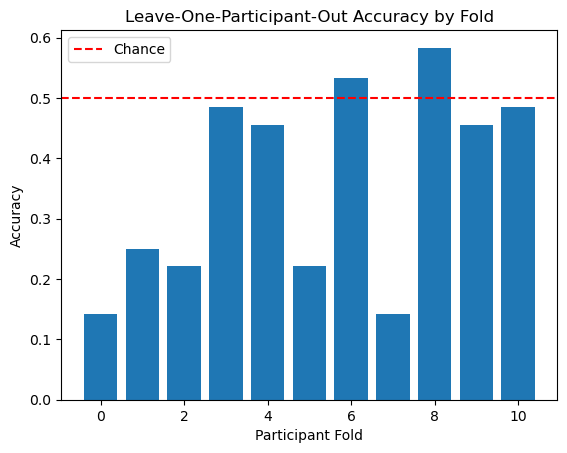

In [15]:
plt.bar(range(len(f1s)), f1s)
plt.axhline(0.5, color='red', linestyle='--', label='Chance')
plt.xlabel("Participant Fold")
plt.ylabel("Accuracy")
plt.title("Leave-One-Participant-Out Accuracy by Fold")
plt.legend()
plt.show()

In [16]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier

# LABEL_COL = 'binary_label'      
# PARTICIPANT_COL = 'Key'
# df = df_data_all
# df_l = df_labels_all

# models = {
#     "KNN": KNeighborsClassifier(n_neighbors=5),
#     "RF": RandomForestClassifier(n_estimators=100, random_state=42),
#     "SVM": SVC(kernel="rbf", probability=True, random_state=42)
# }

# results_val, results_test = [],[]

# # LOPO
# participants = df[PARTICIPANT_COL].unique()

# for pid in participants:
#     train_df = df[df[PARTICIPANT_COL] != pid]
#     val_df = df[df[PARTICIPANT_COL] == pid]
#     train_l = df_l[df_l[PARTICIPANT_COL] != pid]
#     val_l = df_l[df_l[PARTICIPANT_COL] == pid]

#     X_train, y_train = train_df.drop(columns=["Key"]), train_l[LABEL_COL]
#     X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42, shuffle=True, stratify=train_l[LABEL_COL])
#     X_val, y_val = val_df.drop(columns=["Key"]), val_l[LABEL_COL]

#     record_val, record_test = {}, {}

#     for model_name, model in models.items():
#         model.fit(X_train, y_train)
#         y_pred_val = model.predict(X_val)
#         y_pred_test = model.predict(X_test)
        
#         macro_f1_val = f1_score(y_val, y_pred_val, average='macro')
#         f1_per_class_val = f1_score(y_val, y_pred_val, average=None, labels=np.unique(y_train))
#         record_val = classification_report(y_val, y_pred_val, output_dict=True)

#         macro_f1_test = f1_score(y_test, y_pred_test, average='macro')
#         f1_per_class_test = f1_score(y_test, y_pred_test, average=None, labels=np.unique(y_train))
#         record_test = classification_report(y_test, y_pred_test, output_dict=True)

#         record_val["pid"] = pid
#         record_val["model"]= model_name

#         record_test["pid"] = pid
#         record_test["model"]= model_name

#         results_val.append(record_val)
#         results_test.append(record_test)

# # === Save Results ===
# results_df_val = pd.DataFrame(results_val)
# results_df_test = pd.DataFrame(results_test)

# if save_plots and save_model_results:
#     os.makedirs("results", exist_ok=True)
#     results_df_val.to_csv("results/lopo_sklearn_models.csv", index=False)
#     results_df_test.to_csv("results/main_sklearn_models.csv", index=False)
#     print("Saved Classification Report scores for sklearn models.")
